In [ ]:
VIDEO LINK :-https://drive.google.com/file/d/1KNuYpvefannkYuDacFhZvNPZ-B7FDkAw/view?usp=sharing

#  Customer Churn Prediction Project

### Objective
Customer churn occurs when a customer discontinues a service.  
The goal of this project is to **predict whether a customer will churn** using demographic, account, and service-related data.

### Workflow
1. Load and inspect the dataset  
2. Data cleaning and preprocessing  
3. Exploratory Data Analysis (EDA)  
4. Feature encoding and scaling  
5. Model training and evaluation  
6. Insights and business recommendations


In [2]:
# Import necessary Python libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')


In [3]:
# Load the customer churn dataset
df = pd.read_excel("Customer_data.xlsx")

# Display basic info
print("✅ Dataset loaded successfully!")
df.head()


✅ Dataset loaded successfully!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# View dataset structure
df.info()

# Check number of rows and columns
print("\nShape of dataset:", df.shape)

# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Handle missing TotalCharges by replacing with median value
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert target variable 'Churn' from Yes/No → 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Verify changes
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


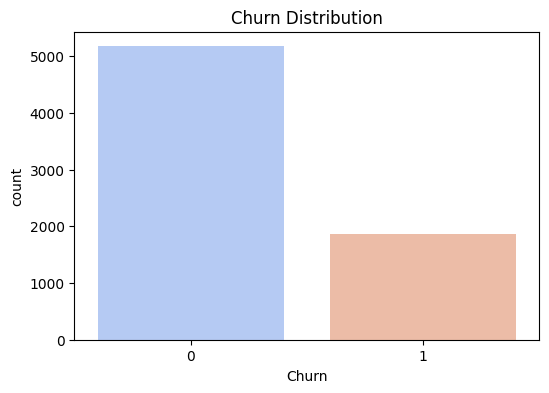

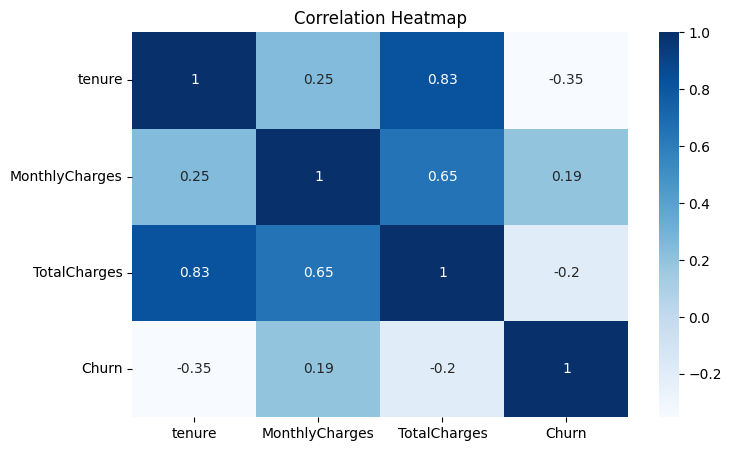

In [6]:
# 1. Churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='coolwarm')
plt.title('Churn Distribution')
plt.show()

# 2. Check numerical features correlation
plt.figure(figsize=(8,5))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()


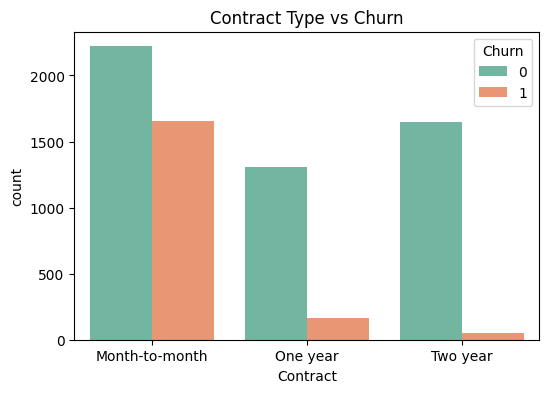

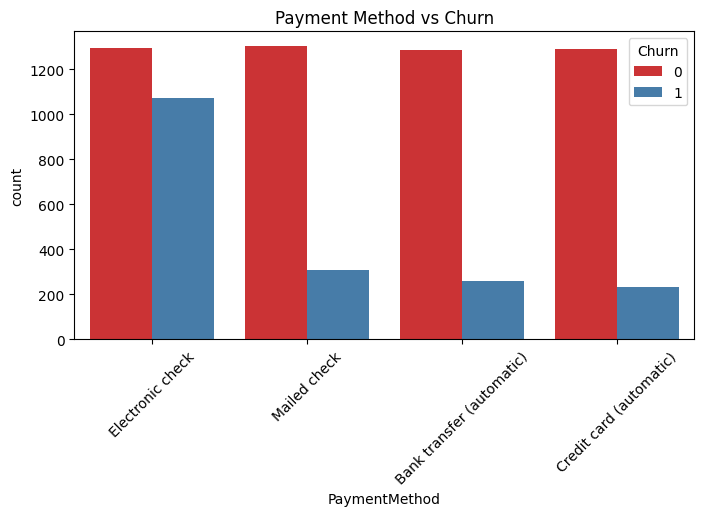

In [7]:
# Relationship between Contract type and Churn
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Contract Type vs Churn')
plt.show()

# Relationship between Payment Method and Churn
plt.figure(figsize=(8,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set1')
plt.xticks(rotation=45)
plt.title('Payment Method vs Churn')
plt.show()


In [8]:
# Identify categorical and numeric columns
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in df.columns if df[col].dtype == 'object' and col != 'customerID']

# Drop customerID as it's not useful
df = df.drop('customerID', axis=1)

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)


Numeric Features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [9]:
# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (5634, 19)
Test set: (1409, 19)


In [10]:
# Preprocess: Scale numeric + encode categorical
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [11]:
# Logistic Regression pipeline
log_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('classifier', LogisticRegression(max_iter=1000))])

# Train model
log_reg_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr = log_reg_pipeline.predict(X_test)


🔹 Logistic Regression Model Performance:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



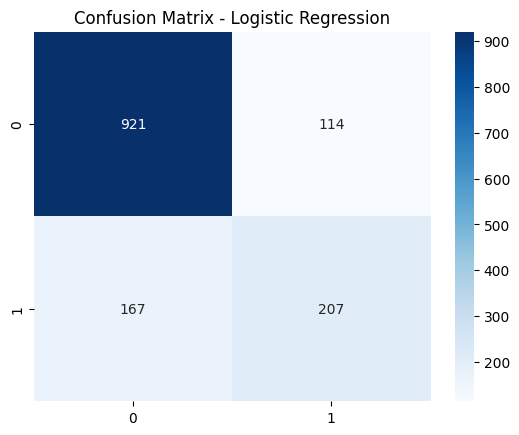

In [12]:
# Evaluate Logistic Regression
print("🔹 Logistic Regression Model Performance:\n")
print(classification_report(y_test, y_pred_lr))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [13]:
# Random Forest pipeline
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate Random Forest
print("🔹 Random Forest Model Performance:\n")
print(classification_report(y_test, y_pred_rf))


🔹 Random Forest Model Performance:

              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.60      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409



In [14]:
# Compare both models in one table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1 Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)]
})

print("📈 Model Comparison:\n")
print(results)


📈 Model Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.800568   0.644860  0.553476  0.595683
1        Random Forest  0.776437   0.600683  0.470588  0.527736


#  Insights and Recommendations

1. **Customers with month-to-month contracts** have the highest churn rate.  
   → Offer long-term discounts to retain them.

2. **Electronic check payment users** churn more than those with automatic payments.  
   → Encourage automatic payments for convenience.

3. **Customers with low tenure** (new users) churn more frequently.  
   → Improve onboarding and early engagement programs.

4. **High monthly charges** correlate with churn.  
   → Introduce flexible pricing or bundled service options.

###  Conclusion
The Random Forest model provides better accuracy and recall, making it suitable for identifying high-risk churn customers.  
The company can use this model to proactively retain valuable customers.
